# 03 — Learning Curves

Visualise data efficiency results from `results/{task}/data_efficiency/results.csv`:

- AUROC and F1 vs training set fraction
- Comparison across architectures and pre-training strategies
- Confidence bands from multiple seeds
- Side-by-side ulcer vs MES comparison

Run **after** executing `scripts/ulcer/run_data_efficiency.py` and/or `scripts/mes/run_data_efficiency.py`.

In [3]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path("..")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams["figure.dpi"] = 120

## Configuration

In [4]:
ULCER_RESULTS = ROOT / "results/ulcer/data_efficiency/results.csv"
ULCER_RAW     = ROOT / "results/ulcer/data_efficiency/results_per_seed.csv"

MES_RESULTS   = ROOT / "results/mes/data_efficiency/results.csv"
MES_RAW       = ROOT / "results/mes/data_efficiency/results_per_seed.csv"

## Filtering plot

In [1]:
# Metrics to plot
METRICS = ["auroc", "f1"]

# Head types to include (None = all)
HEAD_FILTER = ["linear"]

# Models to include (None = all)
MODEL_FILTER: list[str] | None = ["resnet50_5M", "resnet50_imagenet"]
# MODEL_FILTER = ["vits16_imagenet", "efficientnetb0"]

## 1. Load Results

In [18]:
def load_results(path: Path, label: str) -> pd.DataFrame | None:
    if not path.exists():
        print(f"[{label}] Results file not found: {path}")
        return None
    df = pd.read_csv(path)
    print(f"[{label}] {len(df)} rows | models: {df['model'].unique().tolist()}")
    return df

df_ulcer = load_results(ULCER_RESULTS, "ULCER")
df_mes   = load_results(MES_RESULTS,   "MES")

[ULCER] 35 rows | models: ['efficientnetb0', 'resnet50_1M', 'resnet50_200K', 'resnet50_5M', 'resnet50_imagenet', 'vits16_gastronet', 'vits16_imagenet']
[MES] 35 rows | models: ['efficientnetb0', 'resnet50_1M', 'resnet50_200K', 'resnet50_5M', 'resnet50_imagenet', 'vits16_gastronet', 'vits16_imagenet']


## 2. Single-Task Learning Curves

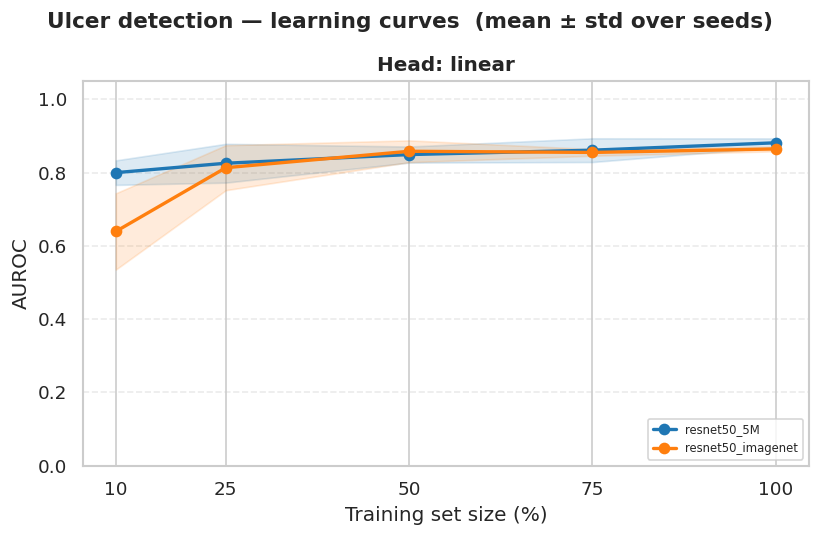

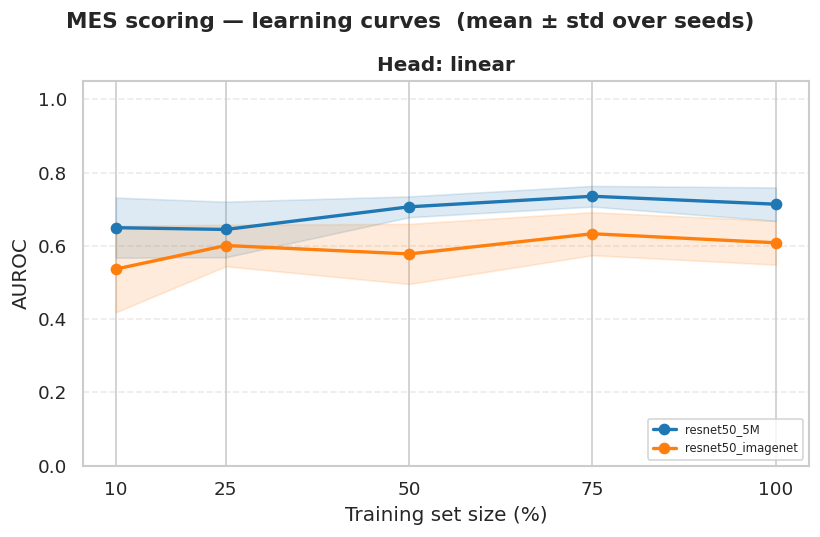

In [19]:
def plot_learning_curves_rich(
    df: pd.DataFrame,
    task: str,
    metrics: list[str] = ("auroc", "f1"),
    head_filter: list[str] | None = None,
    model_filter: list[str] | None = None,
    palette: str = "tab10",
) -> None:
    if df is None:
        return

    if head_filter:
        df = df[df["head_type"].isin(head_filter)]
    if model_filter:
        df = df[df["model"].isin(model_filter)]
    if df.empty:
        print(f"[{task}] No data after filtering.")
        return

    head_types = df["head_type"].unique()
    n_metrics  = len(metrics)
    ncols      = min(len(head_types), 2)
    nrows      = n_metrics * ((len(head_types) + ncols - 1) // ncols)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(7 * ncols, 4 * nrows),
        sharey="row", squeeze=False,
    )
    fig.suptitle(
        f"{task} — learning curves  (mean ± std over seeds)",
        fontsize=13, fontweight="bold",
    )

    colors    = plt.get_cmap(palette).colors
    models    = df["model"].unique()
    color_map = {m: colors[i % len(colors)] for i, m in enumerate(models)}

    heads_per_row = ncols
    for m_idx, metric in enumerate(metrics):
        mean_col = f"{metric}_mean"
        std_col  = f"{metric}_std"
        if mean_col not in df.columns:
            print(f"Column '{mean_col}' not found — skipping '{metric}'")
            continue

        for h_idx, head in enumerate(head_types):
            row = m_idx * ((len(head_types) + heads_per_row - 1) // heads_per_row) + h_idx // heads_per_row
            col = h_idx % heads_per_row
            ax  = axes[row][col]
            sub = df[df["head_type"] == head]

            for model_name, grp in sub.groupby("model"):
                grp   = grp.sort_values("subset_ratio")
                x     = grp["subset_ratio"] * 100
                y     = grp[mean_col]
                y_std = grp[std_col] if std_col in grp.columns else 0
                color = color_map[model_name]
                ax.plot(x, y, marker="o", label=model_name, linewidth=2, color=color)
                ax.fill_between(x, y - y_std, y + y_std, color=color, alpha=0.15)

            ax.set_title(f"Head: {head}" if m_idx == 0 else "", fontweight="bold")
            ax.set_xlabel("Training set size (%)")
            ax.set_ylabel(metric.upper() if col == 0 else "")
            ax.set_xticks([10, 25, 50, 75, 100])
            ax.set_ylim(0, 1.05)
            ax.grid(axis="y", linestyle="--", alpha=0.4)
            ax.legend(loc="lower right", fontsize=7, frameon=True)

    for idx in range(len(head_types), nrows * ncols):
        axes[idx // ncols][idx % ncols].set_visible(False)

    fig.tight_layout()
    plt.show()

plot_learning_curves_rich(df_ulcer, "Ulcer detection", METRICS, HEAD_FILTER, MODEL_FILTER)
plot_learning_curves_rich(df_mes,   "MES scoring",     METRICS, HEAD_FILTER, MODEL_FILTER)

## 3. Per-Seed Raw Results

Each dot = one independent run (seed × ratio). No lines — runs at different ratios share no data.

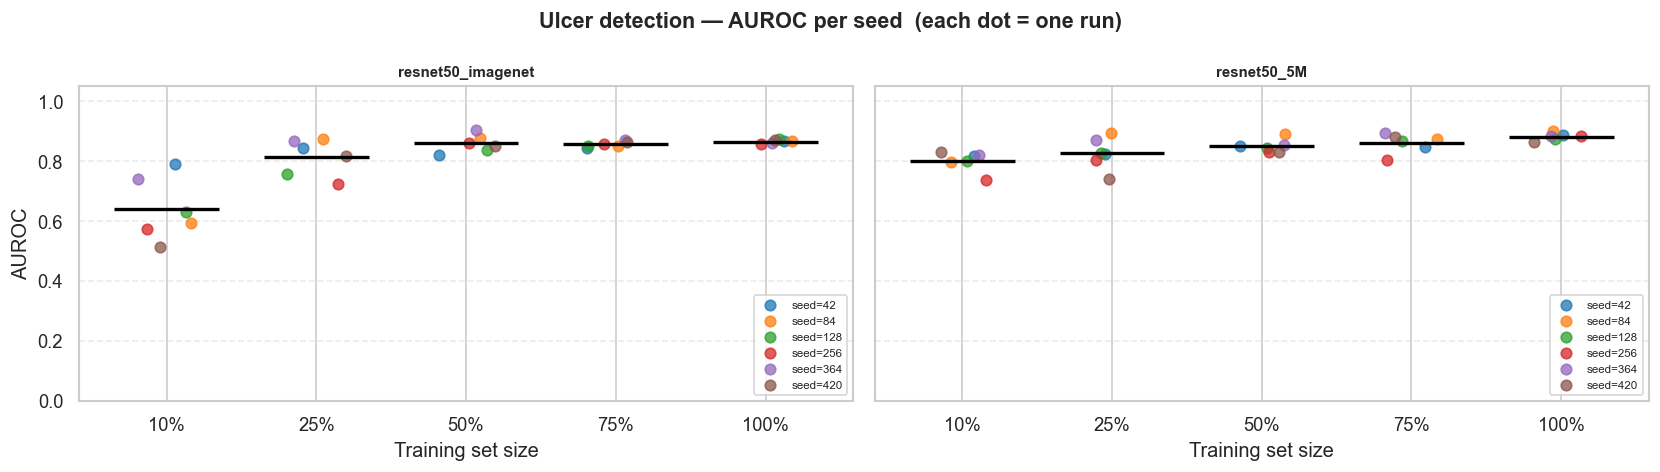

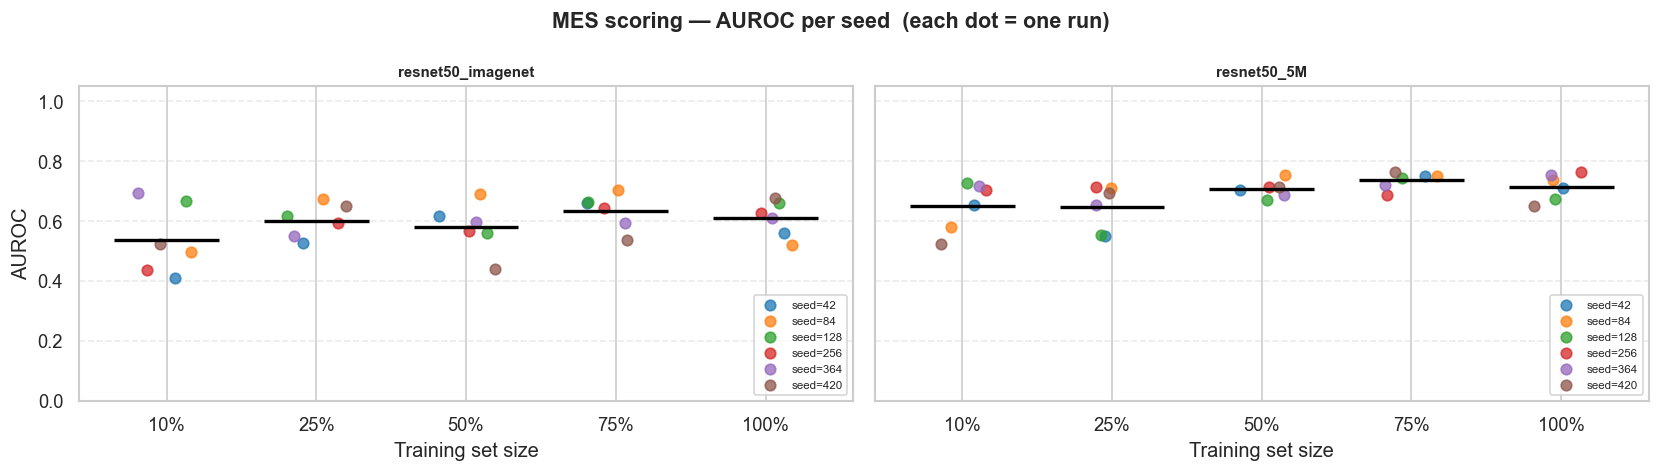

In [6]:
def plot_per_seed_dots(
    path: Path,
    task: str,
    metric: str = "auroc",
    head_filter: list[str] | None = None,
    model_filter: list[str] | None = None,
    jitter: float = 0.8,
) -> None:
    """Strip plot of per-seed results.

    Each dot is one independent run. A horizontal bar marks the mean at each ratio.
    """
    if not path.exists():
        print(f"[{task}] Per-seed file not found: {path}")
        return

    df = pd.read_csv(path)
    if head_filter:
        df = df[df["head_type"].isin(head_filter)]
    if model_filter:
        df = df[df["model"].isin(model_filter)]
    if df.empty:
        print(f"[{task}] No data after filtering.")
        return

    models = df["model"].unique()
    ncols  = min(len(models), 2)
    nrows  = (len(models) + ncols - 1) // ncols
    rng    = __import__("numpy").random.default_rng(0)

    fig, axes = plt.subplots(
        nrows, ncols, figsize=(7 * ncols, 4 * nrows), sharey=True, squeeze=False
    )
    fig.suptitle(
        f"{task} — {metric.upper()} per seed  (each dot = one run)",
        fontsize=13, fontweight="bold",
    )

    colors    = plt.get_cmap("tab10").colors
    seeds     = sorted(df["seed"].unique())
    color_map = {s: colors[i % len(colors)] for i, s in enumerate(seeds)}

    for idx, model_name in enumerate(models):
        ax  = axes[idx // ncols][idx % ncols]
        mdf = df[df["model"] == model_name]

        ratios = sorted(mdf["subset_ratio"].unique())
        x_pos  = {r: i for i, r in enumerate(ratios)}   # categorical x positions

        for seed, sdf in mdf.groupby("seed"):
            xs = [x_pos[r] + rng.uniform(-jitter / 4, jitter / 4) for r in sdf["subset_ratio"]]
            ax.scatter(xs, sdf[metric], color=color_map[seed], alpha=0.75,
                       s=40, zorder=3, label=f"seed={seed}")

        # Mean bar at each ratio
        for r, grp in mdf.groupby("subset_ratio"):
            xp = x_pos[r]
            ax.hlines(grp[metric].mean(), xp - 0.35, xp + 0.35,
                      colors="black", linewidths=2, zorder=4)

        ax.set_title(model_name, fontsize=9, fontweight="bold")
        ax.set_xticks(range(len(ratios)))
        ax.set_xticklabels([f"{int(r * 100)}%" for r in ratios])
        ax.set_xlabel("Training set size")
        ax.set_ylabel(metric.upper() if idx % ncols == 0 else "")
        ax.set_ylim(0, 1.05)
        ax.grid(axis="y", linestyle="--", alpha=0.4)
        ax.legend(fontsize=7, loc="lower right")

    for idx in range(len(models), nrows * ncols):
        axes[idx // ncols][idx % ncols].set_visible(False)

    fig.tight_layout()
    plt.show()


plot_per_seed_dots(ULCER_RAW, "Ulcer detection", metric="auroc", head_filter=HEAD_FILTER, model_filter=MODEL_FILTER)
plot_per_seed_dots(MES_RAW,   "MES scoring",     metric="auroc", head_filter=HEAD_FILTER, model_filter=MODEL_FILTER)

## 4. Relative Gain vs Baseline

Show how much performance improves going from the smallest to the full dataset.

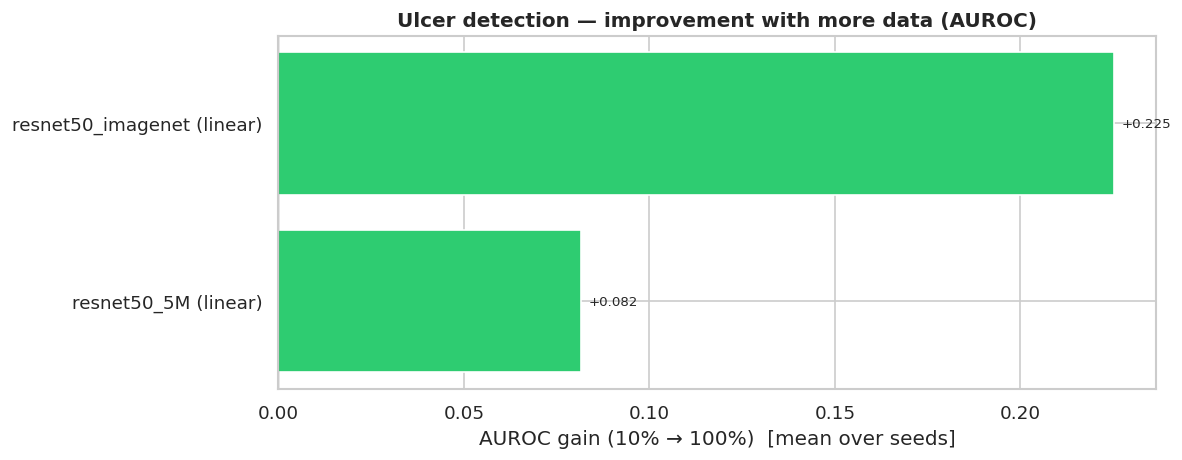

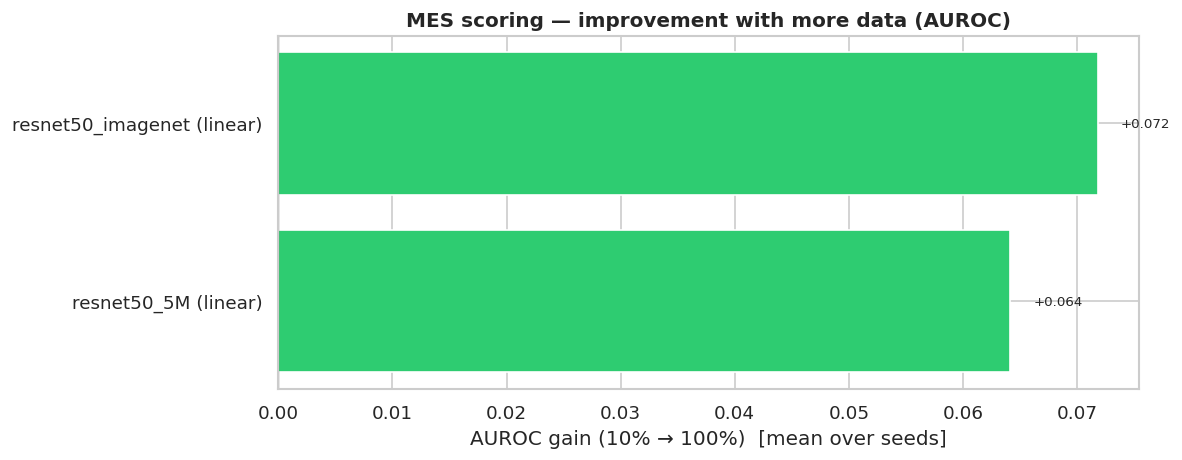

In [21]:
def plot_relative_gain(
    df: pd.DataFrame,
    task: str,
    metric: str = "auroc",
    baseline_ratio: float = 0.10,
    model_filter: list[str] | None = None,
) -> None:
    if df is None:
        return

    if model_filter:
        df = df[df["model"].isin(model_filter)]

    mean_col = f"{metric}_mean"
    if mean_col not in df.columns:
        return

    results = []
    for (model, head), grp in df.groupby(["model", "head_type"]):
        grp = grp.sort_values("subset_ratio")
        baseline_row = grp[grp["subset_ratio"].round(2) == round(baseline_ratio, 2)]
        full_row     = grp[grp["subset_ratio"] == grp["subset_ratio"].max()]
        if baseline_row.empty or full_row.empty:
            continue
        baseline_val = baseline_row[mean_col].values[0]
        full_val     = full_row[mean_col].values[0]
        results.append({"model": model, "head_type": head,
                        "baseline": baseline_val, "full": full_val,
                        "gain": full_val - baseline_val})

    if not results:
        print(f"[{task}] Could not compute relative gains (check subset ratios).")
        return

    rdf    = pd.DataFrame(results).sort_values("gain", ascending=True)
    fig, ax = plt.subplots(figsize=(10, max(4, len(rdf) * 0.5)))
    colors = ["#2ecc71" if g > 0 else "#e74c3c" for g in rdf["gain"]]
    bars   = ax.barh(rdf["model"] + " (" + rdf["head_type"] + ")", rdf["gain"], color=colors)
    for bar, row in zip(bars, rdf.itertuples()):
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
                f"+{row.gain:.3f}", va="center", fontsize=8)
    ax.axvline(0, color="gray", linewidth=0.8)
    ax.set_xlabel(f"{metric.upper()} gain ({int(baseline_ratio*100)}% → 100%)  [mean over seeds]")
    ax.set_title(f"{task} — improvement with more data ({metric.upper()})", fontweight="bold")
    fig.tight_layout()
    plt.show()

plot_relative_gain(df_ulcer, "Ulcer detection", metric="auroc", model_filter=MODEL_FILTER)
plot_relative_gain(df_mes,   "MES scoring",     metric="auroc", model_filter=MODEL_FILTER)

## 5. Ulcer vs MES Side-by-Side (if both available)

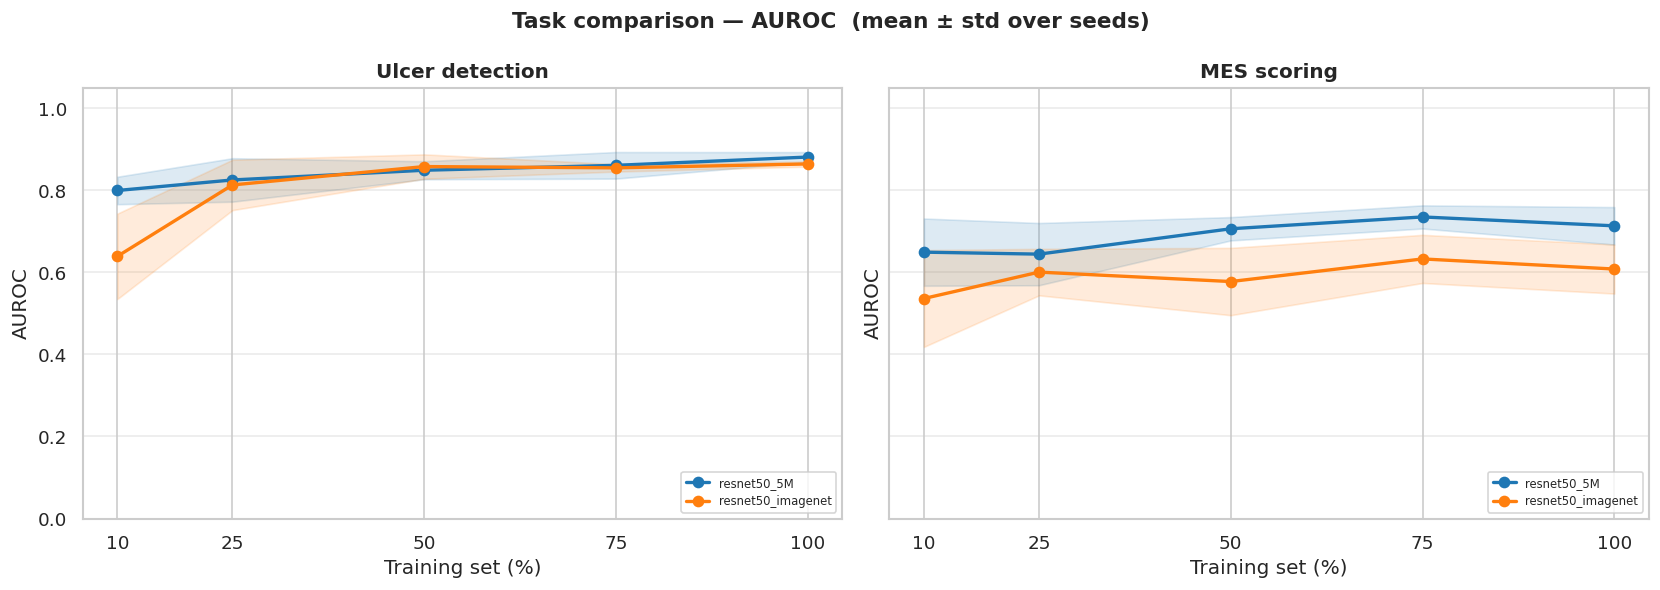

In [22]:
def plot_task_comparison(
    df_a: pd.DataFrame, label_a: str,
    df_b: pd.DataFrame, label_b: str,
    metric: str = "auroc",
    head_filter: list[str] | None = None,
    model_filter: list[str] | None = None,
) -> None:
    if df_a is None or df_b is None:
        print("Both task results needed for comparison.")
        return

    mean_col = f"{metric}_mean"
    std_col  = f"{metric}_std"

    fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    fig.suptitle(
        f"Task comparison — {metric.upper()}  (mean ± std over seeds)",
        fontsize=13, fontweight="bold",
    )

    colors = plt.get_cmap("tab10").colors

    for ax, df, label in [(ax_a, df_a, label_a), (ax_b, df_b, label_b)]:
        if head_filter:
            df = df[df["head_type"].isin(head_filter)]
        if model_filter:
            df = df[df["model"].isin(model_filter)]
        if mean_col not in df.columns:
            continue
        models    = df["model"].unique()
        color_map = {m: colors[i % len(colors)] for i, m in enumerate(models)}

        for model_name, grp in df.groupby("model"):
            grp   = grp.sort_values("subset_ratio")
            x     = grp["subset_ratio"] * 100
            y     = grp[mean_col]
            y_std = grp[std_col] if std_col in grp.columns else 0
            color = color_map[model_name]
            ax.plot(x, y, marker="o", label=model_name, linewidth=2, color=color)
            ax.fill_between(x, y - y_std, y + y_std, color=color, alpha=0.15)

        ax.set_title(label, fontweight="bold")
        ax.set_xlabel("Training set (%)")
        ax.set_ylabel(metric.upper())
        ax.set_ylim(0, 1.05)
        ax.set_xticks([10, 25, 50, 75, 100])
        ax.grid(axis="y", alpha=0.4)
        ax.legend(loc="lower right", fontsize=7)

    fig.tight_layout()
    plt.show()

plot_task_comparison(df_ulcer, "Ulcer detection", df_mes, "MES scoring",
                     metric="auroc", head_filter=HEAD_FILTER, model_filter=MODEL_FILTER)

## 6. Clinical Metrics

Threshold-tuned clinical metrics plotted against training set size:

- **Ulcer detection**: sensitivity, specificity, F1 at the operating point tuned on the validation set
- **MES scoring**: clinical sensitivity (active disease vs remission), specificity, F1

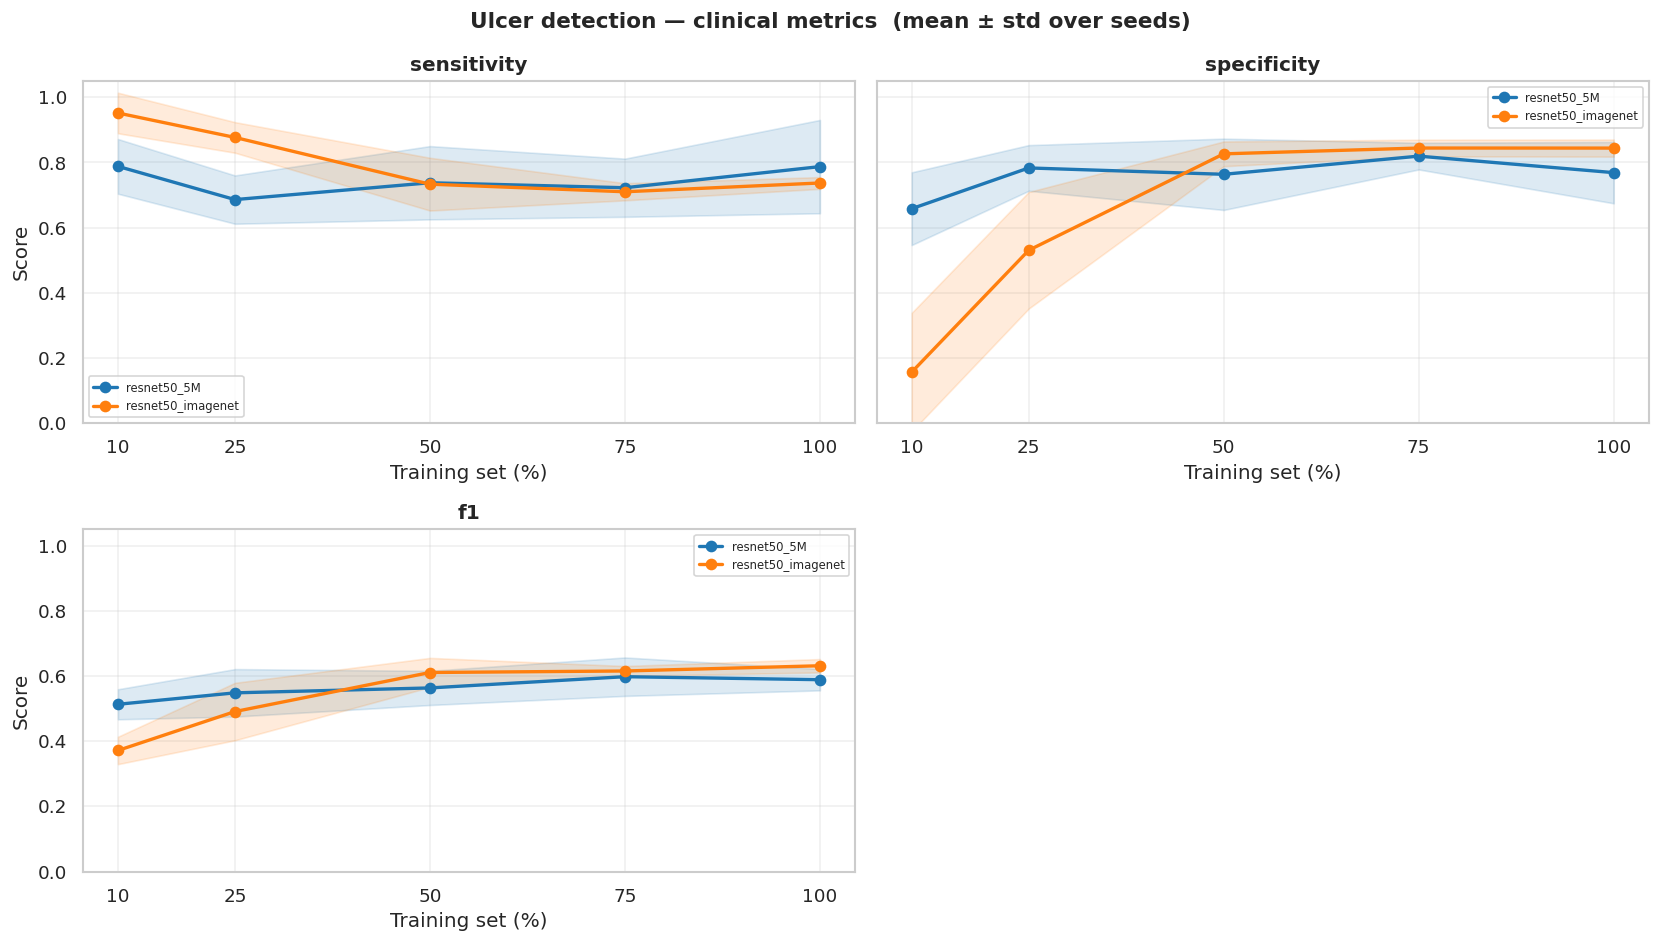

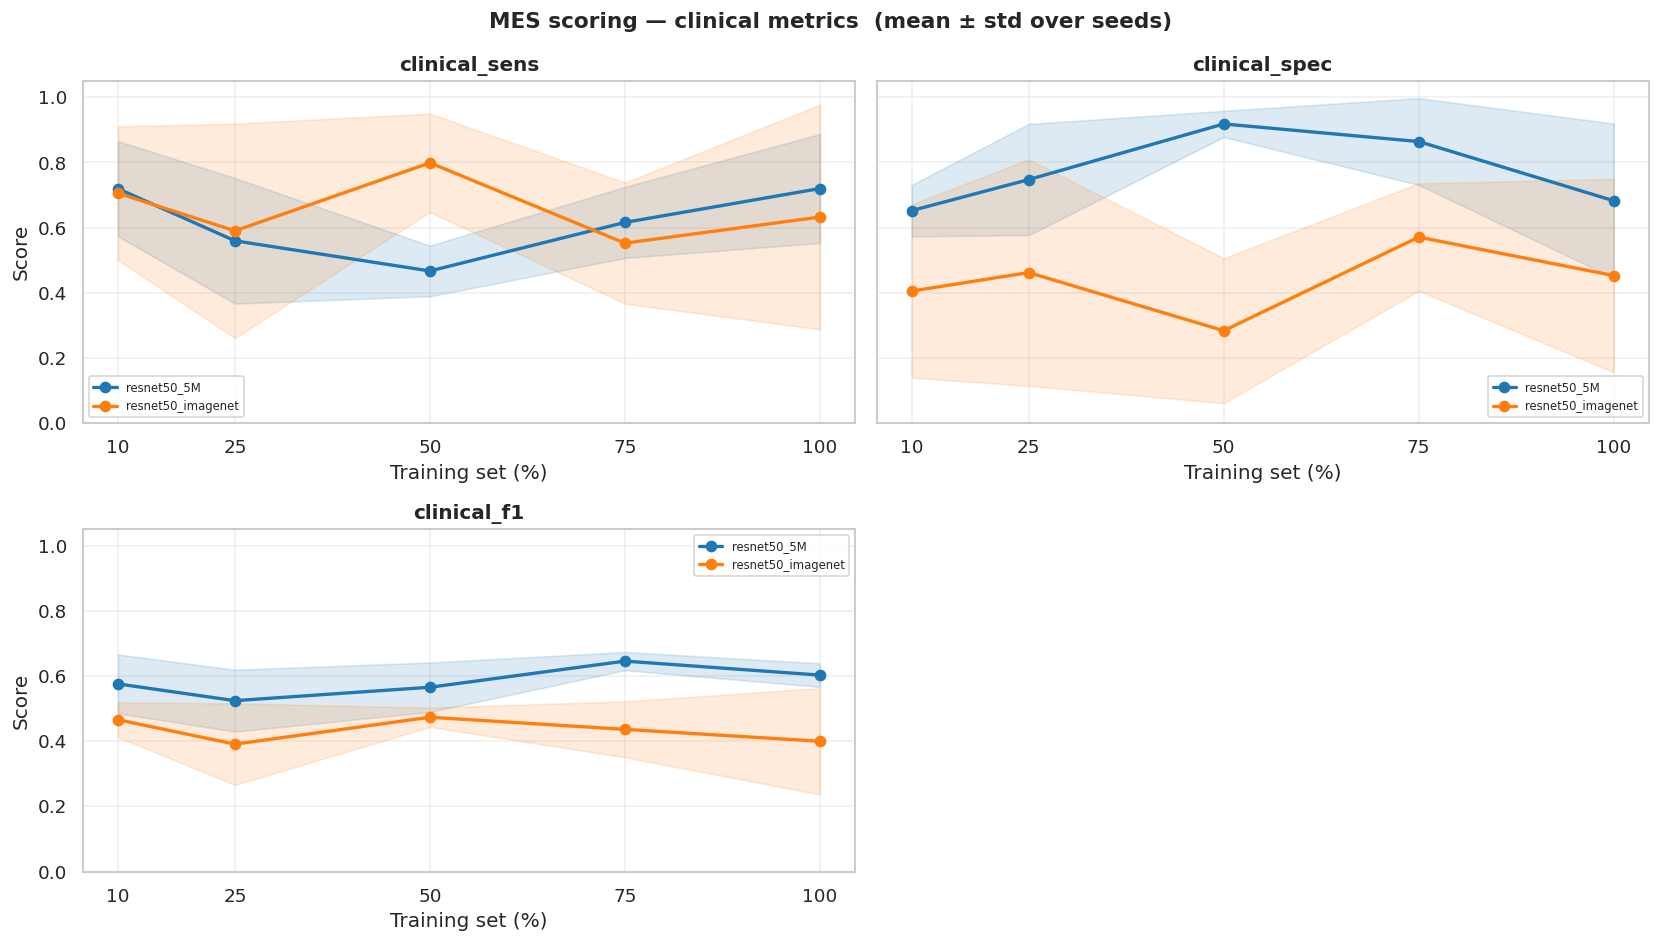

In [23]:
def plot_clinical_metrics(
    df: pd.DataFrame,
    task: str,
    model_filter: list[str] | None = None,
) -> None:
    """Plot clinical metrics vs training set size for ulcer or MES."""
    if df is None:
        return

    if model_filter:
        df = df[df["model"].isin(model_filter)]

    # Ulcer: tuned_sensitivity_mean, tuned_specificity_mean, tuned_f1_mean
    # MES:   cli_sens_mean, cli_spec_mean, cli_f1_mean, macro_f1_mean
    clinical_cols = [
        c for c in df.columns
        if c.endswith("_mean") and any(
            k in c for k in ("cli_", "tuned_sensitivity", "tuned_specificity", "tuned_f1")
        )
    ]
    if not clinical_cols:
        print(f"[{task}] No clinical metric columns found.")
        return

    ncols = min(len(clinical_cols), 2)
    nrows = (len(clinical_cols) + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(7 * ncols, 4 * nrows), sharey=True, squeeze=False)
    fig.suptitle(
        f"{task} — clinical metrics  (mean ± std over seeds)",
        fontsize=13, fontweight="bold",
    )

    colors    = plt.get_cmap("tab10").colors
    models    = df["model"].unique()
    color_map = {m: colors[i % len(colors)] for i, m in enumerate(models)}

    for idx, col in enumerate(clinical_cols):
        ax      = axes[idx // ncols][idx % ncols]
        std_col = col.replace("_mean", "_std")

        for model_name, grp in df.groupby("model"):
            grp   = grp.sort_values("subset_ratio")
            x     = grp["subset_ratio"] * 100
            y     = grp[col]
            y_std = grp[std_col] if std_col in grp.columns else 0
            color = color_map[model_name]
            ax.plot(x, y, marker="o", label=model_name, linewidth=2, color=color)
            ax.fill_between(x, y - y_std, y + y_std, color=color, alpha=0.15)

        label = (col.replace("_mean", "")
                   .replace("cli_", "clinical_")
                   .replace("tuned_", ""))
        ax.set_title(label, fontweight="bold")
        ax.set_xlabel("Training set (%)")
        ax.set_ylabel("Score" if idx % ncols == 0 else "")
        ax.set_ylim(0, 1.05)
        ax.set_xticks([10, 25, 50, 75, 100])
        ax.grid(alpha=0.3)
        ax.legend(fontsize=7)

    for idx in range(len(clinical_cols), nrows * ncols):
        axes[idx // ncols][idx % ncols].set_visible(False)

    fig.tight_layout()
    plt.show()


plot_clinical_metrics(df_ulcer, "Ulcer detection", MODEL_FILTER)
plot_clinical_metrics(df_mes,   "MES scoring",     MODEL_FILTER)